# tSZ power spectrum datapoints and the white (shot-noise) normalization

We reload the cached masked tSZ power spectra from notebook 09 (`data/nb09_tsz_map_ps.npz`, `data/nb09_tsz_theory_ps.npz`) and overlay the **white shot-noise level** of the surviving (undetected) clusters for each masking threshold.

A population of clusters acts, on large scales, as Poisson-distributed point sources of integrated Compton-$y$. Each halo has an angular integrated signal
$$Y^{\rm ang}_i = \frac{Y_{5R500c,i}}{D_A(z_i)^2}\quad[\mathrm{sr}],$$
and a Poisson source population has a flat (white) angular power spectrum equal to the mean-square flux per unit solid angle,
$$C_\ell^{\rm white} = \frac{1}{4\pi}\sum_i \left(Y^{\rm ang}_i\right)^2 .$$
This is the **low-$\ell$ limit** of the 1-halo $C_\ell^{yy}$: the cluster profile is unresolved for $\ell\lesssim1/\theta_{500}$, so $C_\ell\to C_\ell^{\rm white}$ there. After masking the **detected** clusters ($q>q_{\rm cat}$), the residual white level is the same sum restricted to the **survivors** ($q<q_{\rm cat}$), so masking lowers the plateau. We plot $D_\ell^{\rm white}=\ell(\ell+1)C_\ell^{\rm white}/2\pi$ (a rising $\ell^2$ line on this axis) for each threshold.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from flamingo import paths
from flamingo.catalogue import load_catalogue
from flamingo.catalogue import frame

Q_CUTS = [50, 20, 10, 5]
LMAX = 6000

# Cached datapoints from notebook 09 (no NaMaster recompute needed).
mp = np.load(paths.DATA / 'nb09_tsz_map_ps.npz')
th = np.load(paths.DATA / 'nb09_tsz_theory_ps.npz')
ellb = mp['ellb']
dl_map = mp['dl_map']
dl_map_masked = {qc: mp[f'dl_q{qc}'] for qc in Q_CUTS}
ell_th = th['ell']
dl_th_full = th['dl_full']
dl_th_masked = {qc: th[f'dl_q{qc}'] for qc in Q_CUTS}
print('loaded cached spectra | map bandpowers', len(ellb), '| theory points', len(ell_th))

loaded cached spectra | map bandpowers 199 | theory points 40


## White shot-noise normalization $C_\ell^{\rm white}=\sum (Y^{\rm ang})^2/4\pi$

Computed from the derived $B=1$ catalogue: the angular integrated $y$ per halo, then the mean-square sum over the clusters surviving each $q$ cut.

In [ ]:
df = load_catalogue(paths.HYDRO / 'catalogue' / 'halo_catalogue_M500c_5e13_zlt3_y0q_arnaudB1.csv')
df = df[np.isfinite(df['q'])]

# Angular integrated Compton-y per halo: Y_ang = Y_5R500c / D_A(z)^2  [sr].
dA = frame.angular_diameter_distance(df['z'].values)          # proper Mpc (hmfast D3A)
y_ang = df['Y_5R500c_Mpc2'].values / dA**2
qv = df['q'].values

C_white_full = np.sum(y_ang**2) / (4 * np.pi)
C_white = {qc: np.sum(y_ang[qv < qc]**2) / (4 * np.pi) for qc in Q_CUTS}
print(f'C_white full sky        = {C_white_full:.4e}')
for qc in Q_CUTS:
    print(f'C_white survivors q<{qc:<2d} = {C_white[qc]:.4e}  ({int((qv < qc).sum())} clusters)')

C_white full sky        = 2.9427e-16
C_white survivors q<50 = 2.8808e-16  (1555540 clusters)
C_white survivors q<20 = 2.3035e-16  (1555450 clusters)
C_white survivors q<10 = 7.0805e-17  (1555006 clusters)
C_white survivors q<5  = 1.2616e-17  (1553150 clusters)


## Datapoints with the white-normalization lines

Map bandpowers (points), completeness theory (solid), and the white shot-noise level (dotted) for the full sky and each $q$ cut. The white line is the low-$\ell$ limit; the measured $C_\ell$ peels away from it above $\ell\sim1/\theta_{500}$ as the cluster profiles are resolved.

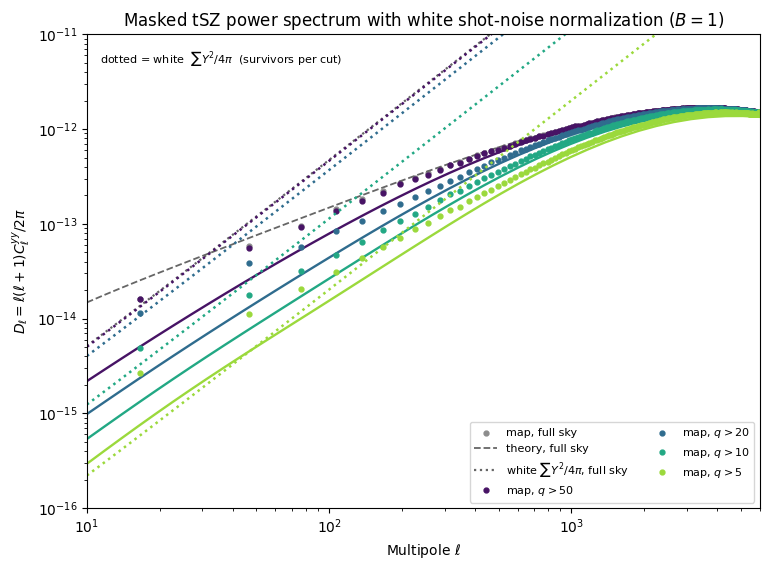

In [ ]:
import matplotlib as mpl

cmap = mpl.colormaps['viridis']
qcolors = {50: cmap(0.05), 20: cmap(0.35), 10: cmap(0.60), 5: cmap(0.85)}
ell_w = np.logspace(1.0, np.log10(LMAX), 100)
dl_white = lambda C: ell_w * (ell_w + 1) / (2 * np.pi) * C

fig, ax = plt.subplots(figsize=(7.8, 5.8))
ax.loglog(ellb, dl_map, 'o', ms=3.5, color='0.55', label='map, full sky')
ax.loglog(ell_th, dl_th_full, '--', lw=1.3, color='0.4', label='theory, full sky')
ax.loglog(ell_w, dl_white(C_white_full), ':', lw=1.6, color='0.4',
          label=r'white $\sum Y^2/4\pi$, full sky')
for qc in Q_CUTS:
    ax.loglog(ellb, dl_map_masked[qc], 'o', ms=3.5, color=qcolors[qc], label=fr'map, $q>{qc}$')
    ax.loglog(ell_th, dl_th_masked[qc], '-', lw=1.7, color=qcolors[qc])
    ax.loglog(ell_w, dl_white(C_white[qc]), ':', lw=1.8, color=qcolors[qc])
ax.set_xlabel(r'Multipole $\ell$')
ax.set_ylabel(r'$D_\ell = \ell(\ell+1)C_\ell^{yy}/2\pi$')
ax.set_title(r'Masked tSZ power spectrum with white shot-noise normalization ($B=1$)')
ax.set_xlim(10, LMAX)
ax.set_ylim(1e-16, 1e-11)
ax.legend(fontsize=8, ncol=2, loc='lower right')
ax.text(0.02, 0.97, 'dotted = white  $\\sum Y^2/4\\pi$  (survivors per cut)',
        transform=ax.transAxes, va='top', fontsize=8)
fig.tight_layout(); plt.show()